In [1]:
import os
from google.colab import userdata

# This is secure because it doesn't show your key in the text!
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

print("Kaggle credentials set securely!")


Kaggle credentials set securely!


In [ ]:
# 1. Download the zip file
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# 2. Unzip it instantly
!unzip -q chest-xray-pneumonia.zip


Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:13<00:00, 18.5MB/s]



In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Define the Preprocessing logic (Data Augmentation)
datagen = ImageDataGenerator(
    rescale=1./255,            # Normalize pixels to 0-1
    rotation_range=10,         # Step 3: Apply rotation
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,            # Step 3: Apply zoom
    horizontal_flip=True,      # Step 3: Apply flipping
    validation_split=0.2       # Reserve 20% for testing the AI later
)

# 2. Load the dataset from the folder we just unzipped
train_data = datagen.flow_from_directory(
    "chest_xray/train",        # The path to your unzipped folder
    target_size=(256, 256),    # Step 3: Resize images to 256x256
    color_mode="grayscale",    # Step 3: Convert to grayscale
    batch_size=32,
    class_mode="binary",       # Normal vs Pneumonia
    subset="training"
)

print("Step 3 Successful: Images are preprocessed and ready!")


Found 4173 images belonging to 2 classes.
Step 3 Successful: Images are preprocessed and ready!


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# 1. Build the CNN model (As per Tutor's Step 4 architecture)
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(256, 256, 1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Helps prevent the model from just memorizing images
    Dense(1, activation='sigmoid') # Final output: 0 for Normal, 1 for Pneumonia
])

# 2. Compile Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Train Model (We will do 5 epochs to start)
print("Starting Training... This may take a few minutes.")
history = model.fit(train_data, epochs=5)

# 4. Save the model for your GitHub portfolio
model.save("medical_ai_model.h5")
print("Step 4 Complete: Model is trained and saved!")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting Training... This may take a few minutes.
Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 61s 403ms/step - accuracy: 0.8045 - loss: 0.5658
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 48s 368ms/step - accuracy: 0.8828 - loss: 0.2686
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 48s 363ms/step - accuracy: 0.8974 - loss: 0.2500
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 48s 366ms/step - accuracy: 0.9087 - loss: 0.2364
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 48s 367ms/step - accuracy: 0.9125 - loss: 0.2167


Step 4 Complete: Model is trained and saved!


Found 624 images belonging to 2 classes.
AI is analyzing test images...
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 230ms/step

Final Test Accuracy: 85.58%


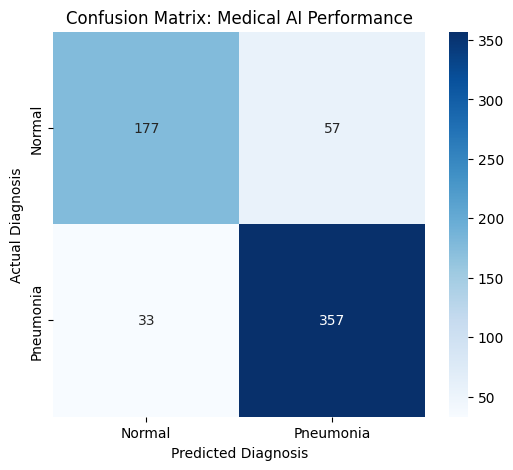

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the test data (Step 5 setup)
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    "chest_xray/test",
    target_size=(256, 256),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

# 2. Predict on test images
print("AI is analyzing test images...")
y_true = test_data.classes
predictions = model.predict(test_data)
y_pred = np.round(predictions).flatten()

# 3. Compute accuracy and generate Confusion Matrix
acc = accuracy_score(y_true, y_pred)
print(f"\nFinal Test Accuracy: {acc * 100:.2f}%")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.title('Confusion Matrix: Medical AI Performance')
plt.show()


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Use a new image from the test folder
sample_path = "chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg"

def virtual_doctor_report(img_path):
    # Preprocess the image
    img = image.load_img(img_path, target_size=(256, 256), color_mode="grayscale")
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    prediction = model.predict(img_array)
    result = "PNEUMONIA DETECTED" if prediction > 0.5 else "NORMAL / HEALTHY"
    confidence = prediction[0][0] if prediction > 0.5 else (1 - prediction[0][0])

    # Industry-style Output
    print("\n" + "="*40)
    print("🏥 AI RADIOLOGY ASSISTANT - FINAL REPORT")
    print("="*40)
    print(f"DIAGNOSIS    : {result}")
    print(f"CONFIDENCE   : {confidence * 100:.2f}%")
    print("-" * 40)
    print("Status: Analysis Complete. Please verify with a Radiologist.")
    print("="*40)

# Execute the simulation
virtual_doctor_report(sample_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

🏥 AI RADIOLOGY ASSISTANT - FINAL REPORT
DIAGNOSIS    : PNEUMONIA DETECTED
CONFIDENCE   : 52.03%
----------------------------------------
Status: Analysis Complete. Please verify with a Radiologist.


In [4]:
import os
from getpass import getpass

# 1. Configuration (Updated with your specific links)
REPO_URL = "https://github.com/Diya927/-AI-Powered-Medical-Image-Analysis"
FILE_TO_SCRUB = "AI Powered Medical Image Analysis.ipynb"

# 2. Install tool and Setup identity
!pip install git-filter-repo
!git config --global user.email "your-email@example.com"
!git config --global user.name "Diya927"

# 3. Clone and Scrub
# We use !rm -rf to clear previous failed attempts first
!rm -rf repo_temp
!git clone {REPO_URL} repo_temp
%cd repo_temp
!git filter-repo --invert-paths --path "{FILE_TO_SCRUB}"

# 4. Secure Push back to GitHub
# Paste your ghp_... token into the box when it appears
token = getpass('Enter your GitHub Personal Access Token: ')
push_url = REPO_URL.replace("https://", f"https://Diya927:{token}@")

!git remote add origin-clean {push_url}
!git push origin-clean --force --all


Cloning into 'repo_temp'...
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 11 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (11/11), 201.41 KiB | 7.75 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/repo_temp
NOTICE: Removing 'origin' remote; see 'Why is my origin removed?'
        in the manual if you want to push back there.
        (was https://github.com/Diya927/-AI-Powered-Medical-Image-Analysis)
Parsed 3 commits
New history written in 0.04 seconds; now repacking/cleaning...
Repacking your repo and cleaning out old unneeded objects
HEAD is now at 39e7061 Revise README with project details and structure
Enumerating objects: 11, done.
Counting objects: 100% (11/11), done.
Delta compression using up to 2 threads
Compressing objects: 100% (9/9), done.
Writing objects: 100% (11/11), done.
Total 11 (delta 1), reused 8 (delta 1), pack-reused 0
Com